#  Data Science with Python Internship – Task 2
## Titanic Dataset Analysis

**Name:** Shefin Hashir K

**Internship:** MainCrafts Technology

## Introduction
This notebook analyzes the Titanic dataset by cleaning missing values, answering survival-related questions, and visualizing the results.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)


## Upload Dataset

In [ ]:
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Explore Dataset

In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.info()
df.describe()

Rows: 891
Columns: 12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Missing Values

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## Data Cleaning

In [ ]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df.drop("Cabin", axis=1, inplace=True)
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## Question 1: Who survived more?

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


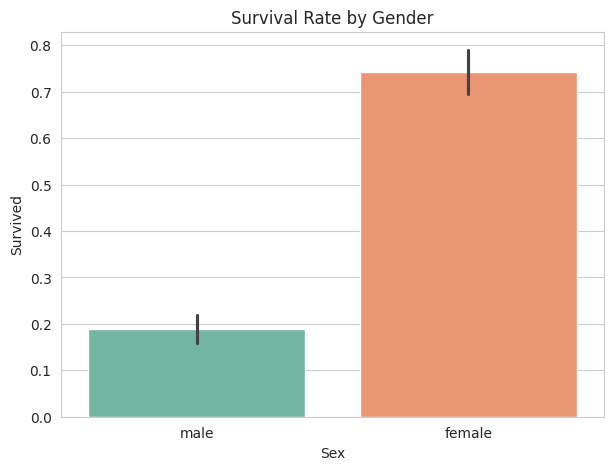

In [ ]:
gender_survival = df.groupby("Sex")["Survived"].mean()
print(gender_survival)

plt.figure(figsize=(7,5))
sns.barplot(data=df, x="Sex", y="Survived", hue="Sex", palette="Set2", legend=False)
plt.title("Survival Rate by Gender")
plt.show()

**Observation:** Female passengers had a much higher survival rate than male passengers.

## Question 2: Did passenger class affect survival?

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


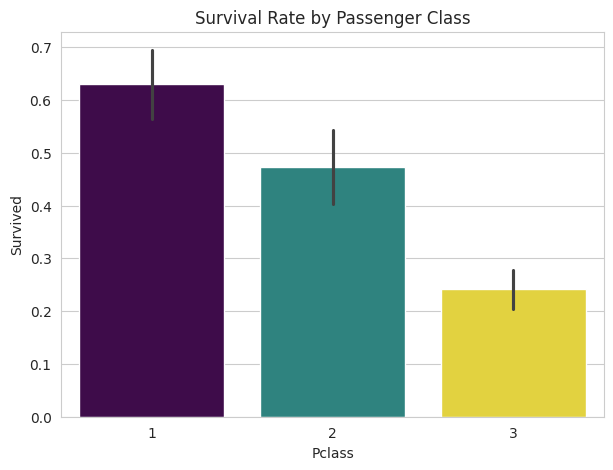

In [ ]:
class_survival = df.groupby("Pclass")["Survived"].mean()
print(class_survival)

plt.figure(figsize=(7,5))
sns.barplot(data=df, x="Pclass", y="Survived", hue="Pclass", palette="viridis", legend=False)
plt.title("Survival Rate by Passenger Class")
plt.show()

**Observation:** First Class passengers had the highest survival rate.

## Question 3: Survival rate by age group

/tmp/ipykernel_463/3180956294.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival=df.groupby("Age Group")["Survived"].mean()


Age Group
Child         0.579710
Teenager      0.428571
Adult         0.353271
Middle Age    0.400000
Senior        0.227273
Name: Survived, dtype: float64


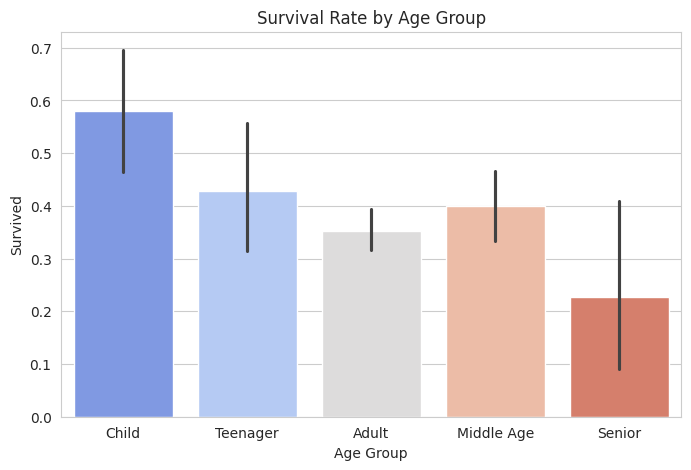

In [ ]:
bins=[0,12,18,35,60,100]
labels=["Child","Teenager","Adult","Middle Age","Senior"]
df["Age Group"]=pd.cut(df["Age"], bins=bins, labels=labels)

age_survival=df.groupby("Age Group")["Survived"].mean()
print(age_survival)

plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Age Group", y="Survived", hue="Age Group", palette="coolwarm", legend=False)
plt.title("Survival Rate by Age Group")
plt.show()

**Observation:** Children generally had higher survival rates.

## Histogram of Passenger Ages

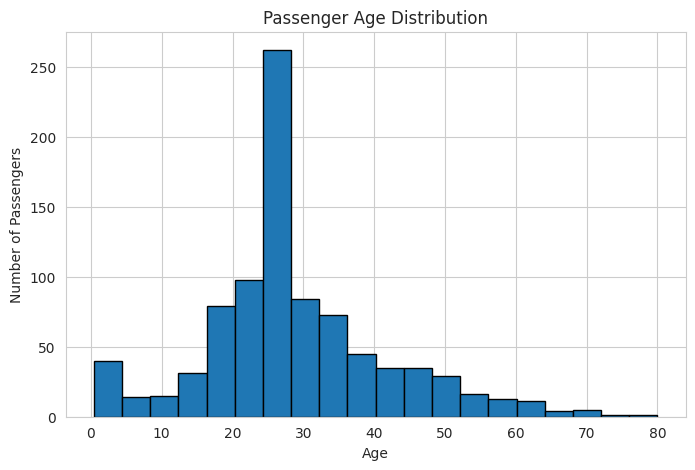

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=20, edgecolor="black")
plt.title("Passenger Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

# Final Conclusion

- Female passengers survived more than males.
- First Class passengers had the highest survival rate.
- Children generally had better survival chances.
- Most passengers were between 20 and 40 years old.
- Data cleaning improved the quality of the analysis.
